In [1]:
## Import Libraries/packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import kagglehub
import tempfile
import datetime as dt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, precision_recall_curve, auc, precision_score, recall_score
from sklearn import set_config
set_config(display="diagram")

In [18]:
kagglehub.login()

## Downloading data from kaggle

In [25]:
path = kagglehub.dataset_download("kartik2112/fraud-detection")
print(f"Dataset cached at: {path}")

files = os.listdir(path)
print(files)

Dataset cached at: /Users/nikhilgupta/.cache/kagglehub/datasets/kartik2112/fraud-detection/versions/1
['fraudTrain.csv', 'fraudTest.csv']


In [2]:
path = "/Users/nikhilgupta/.cache/kagglehub/datasets/kartik2112/fraud-detection/versions/1"
train_df = pd.read_csv(f"{path}/fraudTrain.csv", index_col=0)
test_df = pd.read_csv(f"{path}/fraudTest.csv", index_col=0)

## Data exploration

In [14]:
train_df.head(2)

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0


In [31]:
test_df.head(2)

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2020-06-21 12:14:25,2291163933867244,fraud_Kirlin and Sons,personal_care,2.86,Jeff,Elliott,M,351 Darlene Green,...,33.9659,-80.9355,333497,Mechanical engineer,1968-03-19,2da90c7d74bd46a0caf3777415b3ebd3,1371816865,33.986391,-81.200714,0
1,1,2020-06-21 12:14:33,3573030041201292,fraud_Sporer-Keebler,personal_care,29.84,Joanne,Williams,F,3638 Marsh Union,...,40.3207,-110.4360,302,"Sales professional, IT",1990-01-17,324cc204407e99f51b0d6ca0055005e7,1371816873,39.450498,-109.960431,0


In [32]:
train_df.shape, test_df.shape

((1296675, 23), (555719, 23))

In [ ]:
train_df['is_fraud'].value_counts() ## Imbalance data

is_fraud
0    1289169
1       7506
Name: count, dtype: int64

In [ ]:
test_df['is_fraud'].value_counts() ## imbalance data in test as well but no need to do anything will work on this as unseen data for model evaluation

is_fraud
0    553574
1      2145
Name: count, dtype: int64

In [39]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 23 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Unnamed: 0             1296675 non-null  int64  
 1   trans_date_trans_time  1296675 non-null  object 
 2   cc_num                 1296675 non-null  int64  
 3   merchant               1296675 non-null  object 
 4   category               1296675 non-null  object 
 5   amt                    1296675 non-null  float64
 6   first                  1296675 non-null  object 
 7   last                   1296675 non-null  object 
 8   gender                 1296675 non-null  object 
 9   street                 1296675 non-null  object 
 10  city                   1296675 non-null  object 
 11  state                  1296675 non-null  object 
 12  zip                    1296675 non-null  int64  
 13  lat                    1296675 non-null  float64
 14  long              

In [3]:
#split the train_df into categorical and numerical features
train_df_cat = train_df.select_dtypes(include=['object']).copy()
train_df_num = train_df.select_dtypes(include=['int64', 'float64']).copy()

## Numarical column exploration & Feature Engineering

In [16]:
train_df_num.var()

cc_num        1.712974e+36
amt           2.570123e+04
zip           7.232454e+08
lat           2.576383e+01
long          1.893122e+02
city_pop      9.117764e+10
unix_time     1.648984e+14
merch_lat     2.610994e+01
merch_long    1.896429e+02
is_fraud      5.755148e-03
dtype: float64

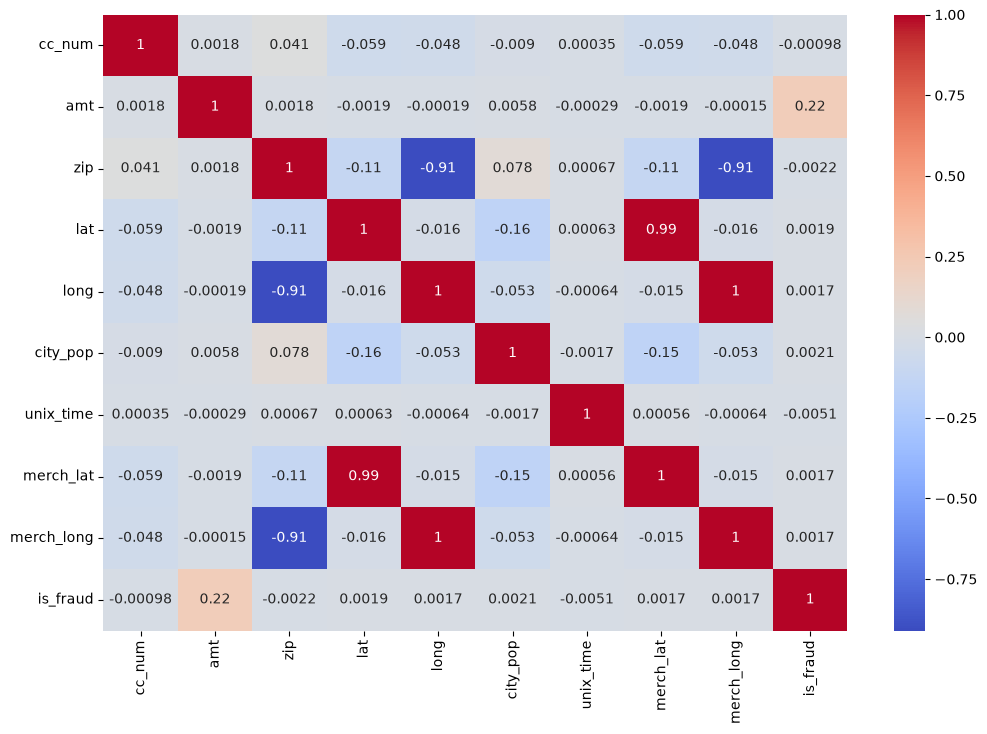

In [17]:
#heat map to visualize correlation between numerical features
plt.figure(figsize=(12, 8))
sns.heatmap(train_df_num.corr(), annot=True, cmap='coolwarm')
plt.show()

In [18]:
corr.columns

Index(['Unnamed: 0', 'cc_num', 'amt', 'zip', 'lat', 'long', 'city_pop',
       'unix_time', 'merch_lat', 'merch_long', 'is_fraud'],
      dtype='object')

In [23]:
# collecting highly correlated columns with correlation coefficient greater than 0.8

corr = train_df_num.corr()
correlated_col = []
for col1 in corr.columns:
    for col2 in corr.columns:
        if col1!=col2 and abs(corr.loc[col1,col2]) >0.8:
            print(f"{col1} and {col2} are highly correlated with correlation coefficient of : {corr.loc[col1,col2]}")
            correlated_col.append((col1, col2))

zip and long are highly correlated with correlation coefficient of : -0.9097321224067211
zip and merch_long are highly correlated with correlation coefficient of : -0.9089240265893989
lat and merch_lat are highly correlated with correlation coefficient of : 0.993592359197498
long and zip are highly correlated with correlation coefficient of : -0.9097321224067211
long and merch_long are highly correlated with correlation coefficient of : 0.9991195818341417
merch_lat and lat are highly correlated with correlation coefficient of : 0.993592359197498
merch_long and zip are highly correlated with correlation coefficient of : -0.9089240265893989
merch_long and long are highly correlated with correlation coefficient of : 0.9991195818341417


In [24]:
correlated_col

[('zip', 'long'),
 ('zip', 'merch_long'),
 ('lat', 'merch_lat'),
 ('long', 'zip'),
 ('long', 'merch_long'),
 ('merch_lat', 'lat'),
 ('merch_long', 'zip'),
 ('merch_long', 'long')]

/var/folders/_x/ltddw3c56kdbv21yt9fmjg4r0000gn/T/ipykernel_598/3870239660.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(train_df_num[col], ax=axes[idx], kde=True)
/var/folders/_x/ltddw3c56kdbv21yt9fmjg4r0000gn/T/ipykernel_598/3870239660.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(t

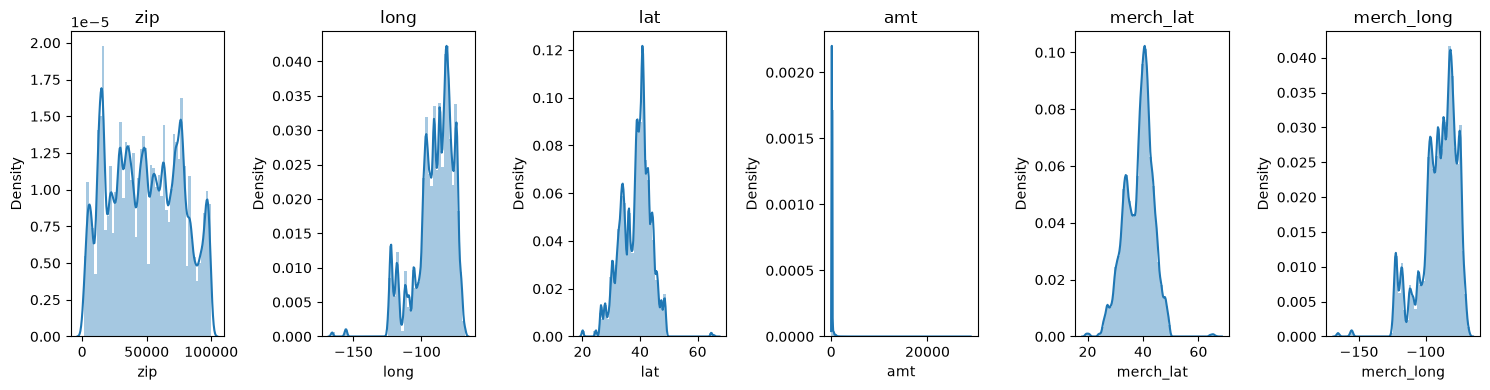

In [30]:
# For specific columns
cols = ['zip', 'long', 'lat','amt','merch_lat','merch_long']

fig, axes = plt.subplots(1, len(cols), figsize=(15, 4))

for idx, col in enumerate(cols):
    sns.distplot(train_df_num[col], ax=axes[idx], kde=True)
    axes[idx].set_title(f"{col}")

plt.tight_layout()
plt.show()

<Axes: ylabel='city_pop'>

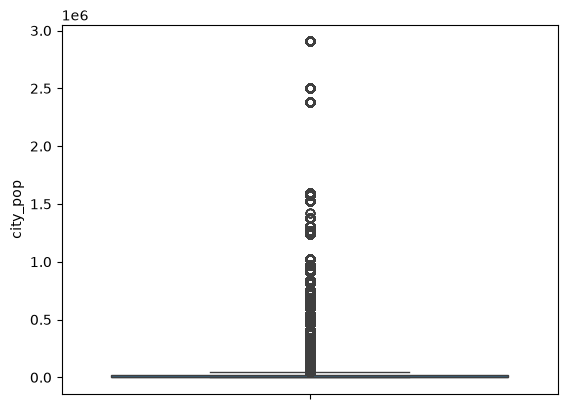

In [63]:
sns.boxplot(y='city_pop', data=train_df_num)

In [4]:
# dropping lat, long, merch_lat, merch_long considerinf the same place also are correlated
# cc_number as well since it's id column and not useful in model building
# cappign amt at 99 and 1 percentile to remove outliers
# capping @ 95 percentile to remove outliers in city_pop column

train_df_num = train_df_num.drop(columns=['lat', 'long', 'merch_lat', 'merch_long','unix_time','cc_num'], axis=1)
train_df_num['amt'] = train_df_num['amt'].clip(lower=train_df_num['amt'].quantile(0.01), upper=train_df_num['amt'].quantile(0.99))
train_df_num['city_pop'] = train_df_num['city_pop'].clip(upper=train_df_num['city_pop'].quantile(0.95))

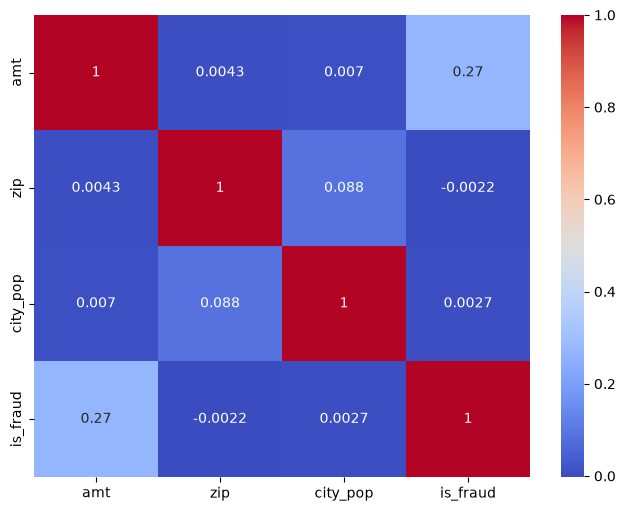

In [115]:
plt.figure(figsize=(8,6))
sns.heatmap(train_df_num.corr(), annot=True, cmap='coolwarm')
plt.show()

<Axes: ylabel='amt'>

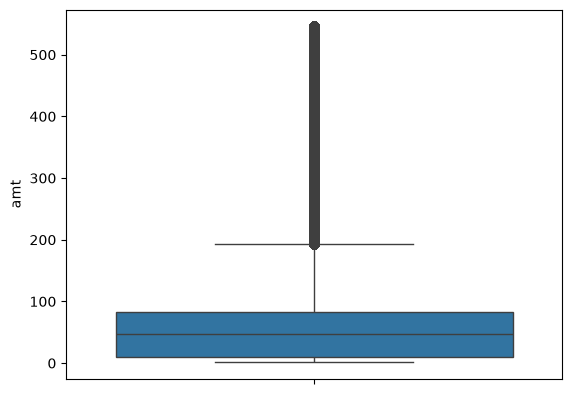

In [48]:
sns.boxplot(y='amt', data=train_df_num)

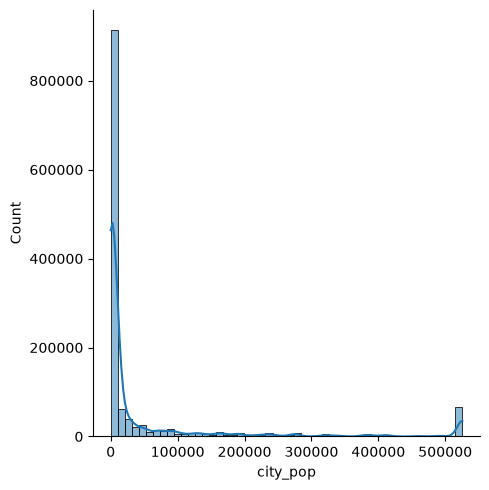

In [96]:
sns.displot(train_df_num['city_pop'], bins=50, kde=True)

In [5]:
# Converting city_zip to catagorical variable since it's a zip code and not a numerical value
train_df_num['zip'] = train_df_num['zip'].astype('object')

In [14]:
train_df_num.head(2)

,amt,zip,city_pop,is_fraud
0,4.97,28654,3495,0
1,107.23,99160,149,0


## Catagorical Column exploration & Feature Engineering

In [121]:
train_df_cat.head(2)

,trans_date_trans_time,merchant,category,first,last,gender,street,city,state,job,dob,trans_num
0,2019-01-01 00:00:18,"fraud_Rippin, Kub and Mann",misc_net,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,NC,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9
1,2019-01-01 00:00:44,"fraud_Heller, Gutmann and Zieme",grocery_pos,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,WA,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99


In [6]:
## Dropping id columns first, last, streat, city, state, trans_num
## Extract time and date from transaction_datetime
train_df_cat = train_df_cat.drop(columns=['first', 'last', 'street', 'city', 'state', 'trans_num'], axis=1)

train_df_cat['date'] = pd.to_datetime(train_df_cat['trans_date_trans_time']).dt.date
train_df_cat['time'] = pd.to_datetime(train_df_cat['trans_date_trans_time']).dt.time

In [125]:
train_df_cat.head(2)

,trans_date_trans_time,merchant,category,gender,job,dob,date,time
0,2019-01-01 00:00:18,"fraud_Rippin, Kub and Mann",misc_net,F,"Psychologist, counselling",1988-03-09,2019-01-01,00:00:18
1,2019-01-01 00:00:44,"fraud_Heller, Gutmann and Zieme",grocery_pos,F,Special educational needs teacher,1978-06-21,2019-01-01,00:00:44


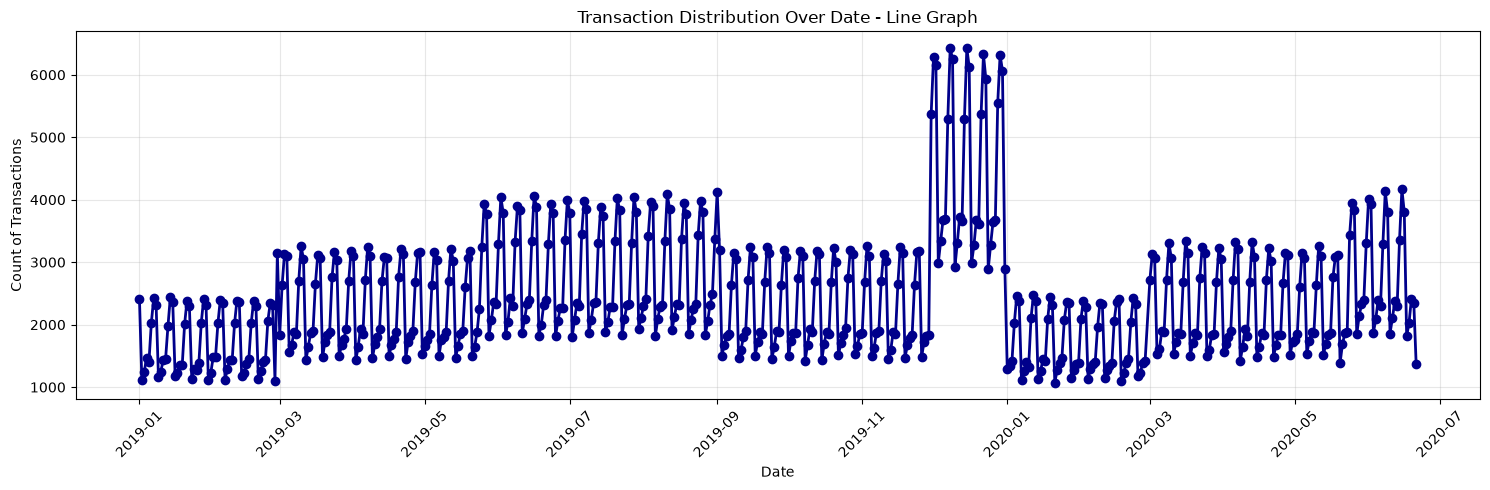

In [ ]:
# Count transactions by date
txn_by_date = train_df_cat['date'].value_counts().sort_index()

# Line graph (distribution)
plt.figure(figsize=(15, 5))
plt.plot(txn_by_date.index, txn_by_date.values, marker='o', linestyle='-', linewidth=2, color='darkblue')
plt.xlabel('Date')
plt.ylabel('Count of Transactions')
plt.title('Transaction Distribution Over Date - Line Graph')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

<BarContainer object of 2 artists>

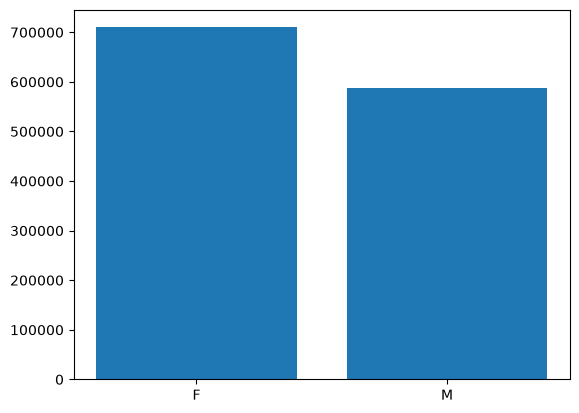

In [129]:
plt.bar(train_df_cat['gender'].value_counts().index, train_df_cat['gender'].value_counts().values)

<BarContainer object of 693 artists>

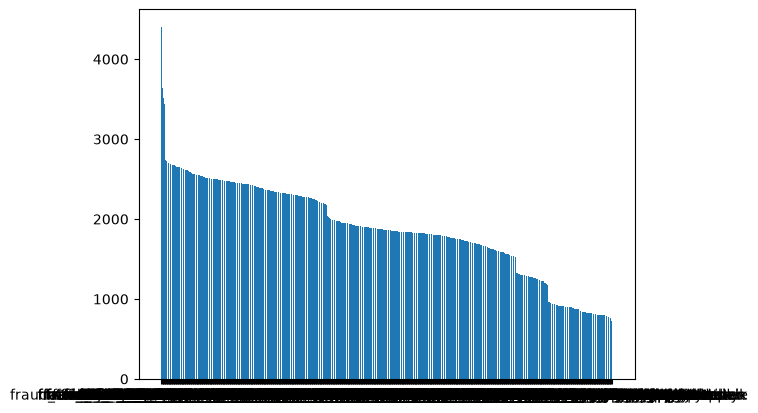

In [130]:
plt.bar(train_df_cat['merchant'].value_counts().index, train_df_cat['merchant'].value_counts().values)

<BarContainer object of 14 artists>

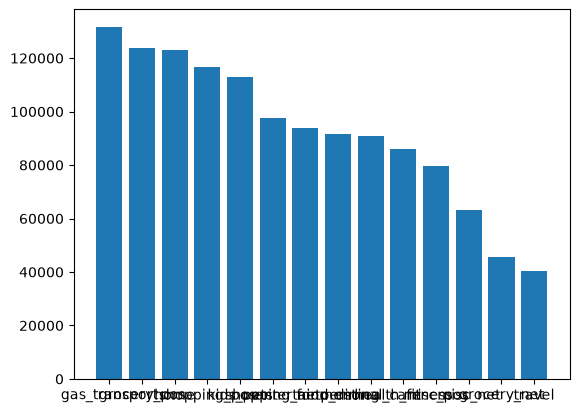

In [131]:
plt.bar(train_df_cat['category'].value_counts().index, train_df_cat['category'].value_counts().values)

<BarContainer object of 494 artists>

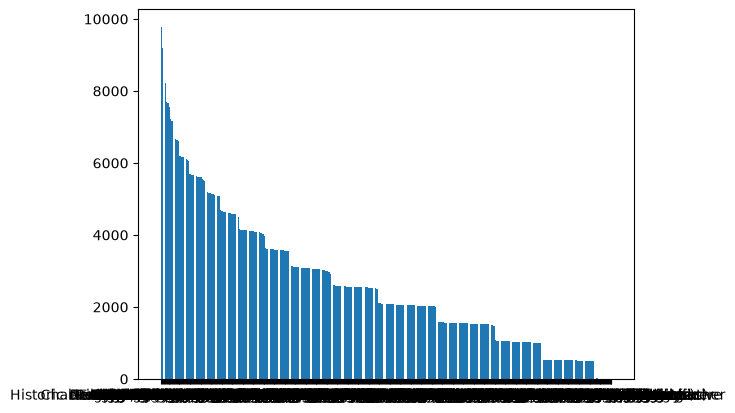

In [132]:
plt.bar(train_df_cat['job'].value_counts().index, train_df_cat['job'].value_counts().values)

In [133]:
train_df_cat['category'].value_counts().index

Index(['gas_transport', 'grocery_pos', 'home', 'shopping_pos', 'kids_pets',
       'shopping_net', 'entertainment', 'food_dining', 'personal_care',
       'health_fitness', 'misc_pos', 'misc_net', 'grocery_net', 'travel'],
      dtype='object', name='category')

In [134]:
train_df_cat['job'].value_counts().index

Index(['Film/video editor', 'Exhibition designer', 'Naval architect',
       'Surveyor, land/geomatics', 'Materials engineer',
       'Designer, ceramics/pottery', 'Systems developer', 'IT trainer',
       'Financial adviser', 'Environmental consultant',
       ...
       'Accountant, chartered', 'Industrial buyer', 'Broadcast journalist',
       'Forest/woodland manager', 'Armed forces technical officer',
       'Information officer', 'Veterinary surgeon', 'Ship broker',
       'Contracting civil engineer', 'Warehouse manager'],
      dtype='object', name='job', length=494)

In [135]:
train_df_cat['merchant'].value_counts().index

Index(['fraud_Kilback LLC', 'fraud_Cormier LLC', 'fraud_Schumm PLC',
       'fraud_Kuhn LLC', 'fraud_Boyer PLC', 'fraud_Dickinson Ltd',
       'fraud_Cummerata-Jones', 'fraud_Kutch LLC',
       'fraud_Olson, Becker and Koch', 'fraud_Stroman, Hudson and Erdman',
       ...
       'fraud_Hodkiewicz, Prohaska and Paucek',
       'fraud_Ritchie, Bradtke and Stiedemann', 'fraud_Tromp Group',
       'fraud_Little-Gleichner', 'fraud_Satterfield-Lowe',
       'fraud_Douglas, DuBuque and McKenzie', 'fraud_Treutel-King',
       'fraud_Medhurst, Labadie and Gottlieb', 'fraud_Reichert-Weissnat',
       'fraud_Hahn, Douglas and Schowalter'],
      dtype='object', name='merchant', length=693)

In [136]:
train_df_cat['gender'].value_counts().index

Index(['F', 'M'], dtype='object', name='gender')

In [7]:
# Creating age column from dob by subtracting from txn date so that we know the pattern
train_df_cat['dob'] = pd.to_datetime(train_df_cat['dob'])
train_df_cat['trans_date_trans_time'] = pd.to_datetime(train_df_cat['trans_date_trans_time'])

train_df_cat['age'] = (train_df_cat['trans_date_trans_time'] - train_df_cat['dob']).dt.days // 365

print(train_df_cat['age'].describe())

count    1.296675e+06
mean     4.552822e+01
std      1.740895e+01
min      1.300000e+01
25%      3.200000e+01
50%      4.400000e+01
75%      5.700000e+01
max      9.500000e+01
Name: age, dtype: float64


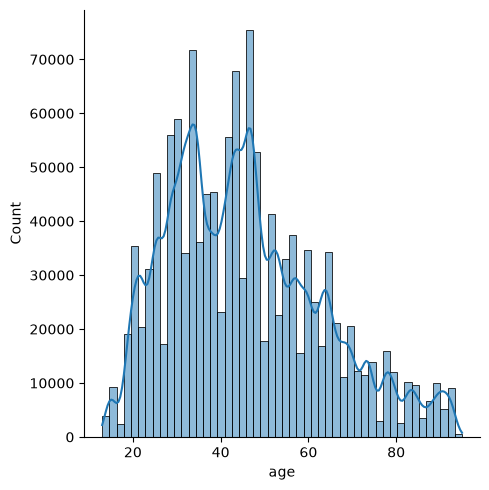

In [138]:
sns.displot(train_df_cat['age'], bins=50, kde=True)

In [140]:
train_df_cat['age'].min(), train_df_cat['age'].max()

(13, 95)

In [8]:
# Drpping datetime, dob column since we have created age column and no longer needed
train_df_cat = train_df_cat.drop(columns=['trans_date_trans_time', 'dob'], axis=1)

In [142]:
train_df_cat.head(2)

,merchant,category,gender,job,date,time,age
0,"fraud_Rippin, Kub and Mann",misc_net,F,"Psychologist, counselling",2019-01-01,00:00:18,30
1,"fraud_Heller, Gutmann and Zieme",grocery_pos,F,Special educational needs teacher,2019-01-01,00:00:44,40


## Merging train catagorical & numerical data

In [144]:
train_df_num.head(2)

,amt,zip,city_pop,is_fraud
0,4.97,28654,3495,0
1,107.23,99160,149,0


In [145]:
train_df_cat.head(2)

,merchant,category,gender,job,date,time,age
0,"fraud_Rippin, Kub and Mann",misc_net,F,"Psychologist, counselling",2019-01-01,00:00:18,30
1,"fraud_Heller, Gutmann and Zieme",grocery_pos,F,Special educational needs teacher,2019-01-01,00:00:44,40


In [10]:
train_df_new = train_df_cat.merge(train_df_num, left_index=True, right_index=True)
train_df_new.head(2)

,merchant,category,gender,job,date,time,age,amt,zip,city_pop,is_fraud
0,"fraud_Rippin, Kub and Mann",misc_net,F,"Psychologist, counselling",2019-01-01,00:00:18,30,4.97,28654,3495,0
1,"fraud_Heller, Gutmann and Zieme",grocery_pos,F,Special educational needs teacher,2019-01-01,00:00:44,40,107.23,99160,149,0


In [148]:
train_df_new.isnull().sum()

merchant    0
category    0
gender      0
job         0
date        0
time        0
age         0
amt         0
zip         0
city_pop    0
is_fraud    0
dtype: int64

In [11]:
# Encode hour cyclically and then considering the day of the week as well for better representation of time features. 
# This is useful for models to understand the cyclical nature of time.

train_df_new['hour'] = train_df_new['time'].apply(lambda x: x.hour)
train_df_new['day_of_week'] = train_df_new['date'].apply(lambda x: x.weekday())

train_df_new['hour_sin'] = np.sin(2 * np.pi * train_df_new['hour'] / 24)
train_df_new['hour_cos'] = np.cos(2 * np.pi * train_df_new['hour'] / 24)
train_df_new['day_sin'] = np.sin(2 * np.pi * train_df_new['day_of_week'] / 7)
train_df_new['day_cos'] = np.cos(2 * np.pi * train_df_new['day_of_week'] / 7)

train_df_new = train_df_new.drop(columns=['date', 'time', 'hour', 'day_of_week'], axis=1)


In [20]:
train_df_new.head(2)

,merchant,category,gender,job,age,amt,zip,city_pop,is_fraud,hour_sin,hour_cos,day_sin,day_cos
0,"fraud_Rippin, Kub and Mann",misc_net,F,"Psychologist, counselling",30,4.97,28654,3495,0,0.0,1.0,0.781831,0.62349
1,"fraud_Heller, Gutmann and Zieme",grocery_pos,F,Special educational needs teacher,40,107.23,99160,149,0,0.0,1.0,0.781831,0.62349


## covnerting test data

In [12]:
test_df['dob'] = pd.to_datetime(test_df['dob'])
test_df['trans_date_trans_time'] = pd.to_datetime(test_df['trans_date_trans_time'])

test_df['age'] = (test_df['trans_date_trans_time'] - test_df['dob']).dt.days // 365

test_df['date'] = pd.to_datetime(test_df['trans_date_trans_time']).dt.date
test_df['time'] = pd.to_datetime(test_df['trans_date_trans_time']).dt.time

test_df['hour'] = test_df['time'].apply(lambda x: x.hour)
test_df['day_of_week'] = test_df['date'].apply(lambda x: x.weekday())

test_df['hour_sin'] = np.sin(2 * np.pi * test_df['hour'] / 24)
test_df['hour_cos'] = np.cos(2 * np.pi * test_df['hour'] / 24)
test_df['day_sin'] = np.sin(2 * np.pi * test_df['day_of_week'] / 7)
test_df['day_cos'] = np.cos(2 * np.pi * test_df['day_of_week'] / 7)

test_df_new = test_df[train_df_new.columns.tolist()]

test_df_new['zip'] = test_df_new['zip'].astype('object')

test_df_new.head(2)

/var/folders/_x/ltddw3c56kdbv21yt9fmjg4r0000gn/T/ipykernel_2244/1839571434.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df_new['zip'] = test_df_new['zip'].astype('object')


,merchant,category,gender,job,age,amt,zip,city_pop,is_fraud,hour_sin,hour_cos,day_sin,day_cos
0,fraud_Kirlin and Sons,personal_care,M,Mechanical engineer,52,2.86,29209,333497,0,1.224647e-16,-1.0,-0.781831,0.62349
1,fraud_Sporer-Keebler,personal_care,F,"Sales professional, IT",30,29.84,84002,302,0,1.224647e-16,-1.0,-0.781831,0.62349


## Train, test split

In [13]:
x_train = train_df_new.drop(columns=['is_fraud'], axis=1)
y_train = train_df_new['is_fraud']

x_test = test_df_new.drop(columns=['is_fraud'], axis=1)
y_test = test_df_new['is_fraud']

## Creating pipeline for data transformation & modeling

In [14]:
from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_curve, roc_auc_score, classification_report, confusion_matrix, f1_score

In [15]:
categorical_features = [col for col in train_df_new.select_dtypes(include=['object']).columns if col != 'gender']
one_hot_cat_features = ['gender']
numerical_features = ['age', 'amt', 'hour_sin', 'hour_cos', 'day_sin', 'day_cos']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('ord_cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), categorical_features),
        ('ohcat', OneHotEncoder(drop='first', handle_unknown='ignore'), one_hot_cat_features)
    ],
    remainder='drop'
)

models = {
    'RandomForest': RandomForestClassifier(class_weight='balanced', n_estimators=100, random_state=42),
    'GradientBoosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'AdaBoost': AdaBoostClassifier(estimator=DecisionTreeClassifier(class_weight='balanced', max_depth=1),n_estimators=100, random_state=42),
    'LogisticRegression': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
}

results = {}
for model_name, model in models.items():
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    
    pipeline.fit(x_train[numerical_features + categorical_features + one_hot_cat_features], y_train)
    
    y_pred = pipeline.predict(x_test[numerical_features + categorical_features + one_hot_cat_features])
    y_pred_proba = pipeline.predict_proba(x_test[numerical_features + categorical_features + one_hot_cat_features])[:, 1]
    
    accuracy = pipeline.score(x_test[numerical_features + categorical_features + one_hot_cat_features], y_test)
    auc = roc_auc_score(y_test, y_pred_proba)
    f1 = f1_score(y_test, y_pred, average='binary')
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    results[model_name] = {'accuracy': accuracy, 'auc_roc': auc, 'precision': precision, 'recall': recall, 'f1-score': f1, 'y_pred': y_pred, 'pipeline': pipeline}
    
    print(f"{model_name}: Accuracy = {accuracy:.4f}, AUC-ROC = {auc:.4f}, Precision = {precision:.4f}, Recall = {recall:.4f}, f1-score = {f1:.4f}")


RandomForest: Accuracy = 0.9985, AUC-ROC = 0.9853, Precision = 0.8466, Recall = 0.7515, f1-score = 0.7962
GradientBoosting: Accuracy = 0.9981, AUC-ROC = 0.9895, Precision = 0.8356, Recall = 0.6280, f1-score = 0.7171
AdaBoost: Accuracy = 0.9712, AUC-ROC = 0.9321, Precision = 0.0935, Recall = 0.7417, f1-score = 0.1660
LogisticRegression: Accuracy = 0.8890, AUC-ROC = 0.9217, Precision = 0.0258, Recall = 0.7557, f1-score = 0.0499


In [ ]:
## Randm forest is giving amazing results
# accuracy = good
# recall = out of 1000 fraud transactions, it is able to identify 800+ transactions which is good.
# precision = out of 1000 transactions which it has identified as fraud, 800+ are actually fraud transactions which is good.
# auc-roc = good, it is able to distinguish between fraud and non-fraud transactions well.

## MLFlow

In [ ]:
import mlflow

In [ ]:
mlflow.set_tracking_uri("http://127.0.0.1:8000")
mlflow.set_experiment("Fraud_credit_card_model")

2026/07/07 23:18:55 INFO mlflow.tracking.fluent: Experiment with name 'Fraud_credit_card_model' does not exist. Creating a new experiment.


<Experiment: artifact_location='mlflow-artifacts:/1', creation_time=1783446535580, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1783446535580, lifecycle_stage='active', name='Fraud_credit_card_model', tags={}, trace_location=None, workspace='default'>

In [ ]:
for model_name, data in results.items():
    
    with mlflow.start_run(run_name=model_name):
        
        pipeline = data['pipeline']
        core_model = pipeline.named_steps['model']
        
        mlflow.log_params(core_model.get_params())
        
        mlflow.log_metric("accuracy", data['accuracy'])
        mlflow.log_metric("auc_roc", data['auc_roc'])
        mlflow.log_metric("f1-score", data['f1-score'])
        mlflow.log_metric("precision", data['precision'])
        mlflow.log_metric("recall", data['recall'])
        # mlflow.log_metric("f1", data['f1'])
        
        sample_input = x_train[numerical_features + categorical_features + one_hot_cat_features].head(5)
        sample_output = pipeline.predict(sample_input)
        data_signature = mlflow.models.infer_signature(model_input=sample_input, model_output=sample_output)
        
        mlflow.sklearn.log_model(
            sk_model=pipeline, 
            artifact_path="model_pipeline", 
            signature=data_signature
        )
        
        cm = confusion_matrix(y_test, data['y_pred'])
        fig, ax = plt.subplots(figsize=(6, 4))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
        plt.title(f'Confusion Matrix - {model_name}')
        plt.ylabel('Actual Label')
        plt.xlabel('Predicted Label')
        
        mlflow.log_figure(fig, f"confusion_matrix_{model_name}.png")
        plt.close(fig) 

print("All runs successfully logged to MLflow UI!")

/opt/homebrew/anaconda3/lib/python3.13/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
2026/07/07 23:51:39 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
/opt/homebrew/anaconda3/lib/python3.13/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains inte

🏃 View run RandomForest at: http://127.0.0.1:8000/#/experiments/1/runs/e5abece9e3b04b4f8a98ab3bcff07306
🧪 View experiment at: http://127.0.0.1:8000/#/experiments/1


/opt/homebrew/anaconda3/lib/python3.13/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
2026/07/07 23:51:49 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


🏃 View run GradientBoosting at: http://127.0.0.1:8000/#/experiments/1/runs/724ecf4360584d2783ba5b638c532118
🧪 View experiment at: http://127.0.0.1:8000/#/experiments/1


/opt/homebrew/anaconda3/lib/python3.13/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
2026/07/07 23:51:53 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


🏃 View run AdaBoost at: http://127.0.0.1:8000/#/experiments/1/runs/532860b89b4243fb98ae2f7121300d45
🧪 View experiment at: http://127.0.0.1:8000/#/experiments/1
🏃 View run LogisticRegression at: http://127.0.0.1:8000/#/experiments/1/runs/06e4a8bc2d83471f945ce070a7a1f81b
🧪 View experiment at: http://127.0.0.1:8000/#/experiments/1
All runs successfully logged to MLflow UI!


## Building ANN/DNN Model [using Pytorch]

In [ ]:
import tensorflow as tf
import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
categorical_features = [col for col in train_df_new.select_dtypes(include=['object']).columns if col != 'gender']
one_hot_cat_features = ['gender']
numerical_features = ['age', 'amt', 'hour_sin', 'hour_cos', 'day_sin', 'day_cos']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('ord_cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), categorical_features),
        ('ohcat', OneHotEncoder(drop='first', handle_unknown='ignore'), one_hot_cat_features)
    ],
    remainder='drop'
)

preprocessor.fit(x_train[numerical_features + categorical_features + one_hot_cat_features])

x_train_preprocessed = preprocessor.transform(x_train[numerical_features + categorical_features + one_hot_cat_features])
x_test_preprocessed = preprocessor.transform(x_test[numerical_features + categorical_features + one_hot_cat_features])

if (y_train < 0).any():
    print("Warning: Found negative values in y_train! Clipping them to 0 and 1.")
    y_train = np.clip(y_train, 0, 1)

classes, counts = np.unique(y_train, return_counts=True)
neg, pos = counts[0], counts[1]
total = neg + pos

weight_for_0 = (1 / neg) * (total / 2.0)
weight_for_1 = (1 / pos) * (total / 2.0)
class_weight = {0: weight_for_0, 1: weight_for_1}

model = Sequential()
model.add(Dense(64, activation='relu', input_shape=(x_train_preprocessed.shape[1],)))
model.add(Dropout(0.5))
model.add(Dense(32, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(1, activation='sigmoid'))

model.compile(loss='binary_crossentropy', optimizer=Adam(learning_rate=0.001), metrics=['accuracy','precision','recall'])

model.fit(x_train_preprocessed, y_train, epochs=10, batch_size=32, validation_split=0.2,class_weight=class_weight, callbacks=[EarlyStopping(patience=3)])
model.summary()

test_evaluation = model.evaluate(x_test_preprocessed, y_test)

## Saving Final Model

In [17]:
import joblib

## RF is shwoing the best results so far, ANN and other models didn't performed well. one major reason in class imbalance.
pkl_filename = "RF_credit_fraud_model.pkl"

best_model_name = 'RandomForest'
best_pipeline = results[best_model_name]['pipeline']

joblib.dump(best_pipeline, pkl_filename)
print(f"Model saved as {pkl_filename}")

Model saved as RF_credit_fraud_model.pkl
